<a href="https://colab.research.google.com/github/saim9211/DeepLearning/blob/main/03_pytorch_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Computer vision is the art of giving power to computer to see

The resources we need to cover is the
link: https://www.learnpytorch.io/03_pytorch_computer_vision/

### computer vision libraries
1.  torchvision.datasets  -> get the datasets and data loading functions for cv here
2.  torchvision.models -> get pretrained cv models that you can leverage for your own prob
3.  torchvision.transform -> function for manipulating your vision data (images) in to suitable for use with ml model
4.  torchvision.utils.data.Dataset -> base dataset class for pytorch
5.  torch.utils.data.DataLoader -> create iterable over a dataset


In [1]:
# import libraries
import torch
from torch import nn

# import the torchvision libraries
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
# libraries for the visualization
import matplotlib.pyplot as plt


### getting the data set of the fashion mnist data set
link:https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST


In [2]:
from torchvision import datasets
train_data=datasets.FashionMNIST(
    root="data", # where to download the data
    train=True,  # do we want he training dataset
    download=True, # do we want o download yes/no
    transform=ToTensor() # how do we want to transform the labels /targets?
    )
test_data=datasets.FashionMNIST(
    root="data", # where to download the data
    train=False,  # do we want he training dataset
    download=True, # do we want o download yes/no
    transform=ToTensor() # how do we want to transform the labels /targets?
)


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.9MB/s]


In [3]:
len(train_data),len(test_data)

(60000, 10000)

In [4]:
# see the first training examples
image,label=train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_name_idx=train_data.class_to_idx
class_name_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [7]:
# check the shape of the images
print(f"image_shape:{image.shape}")
print(f"label:{class_names[label]}")

image_shape:torch.Size([1, 28, 28])
label:Ankle boot


### visualizing  pur data

images shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

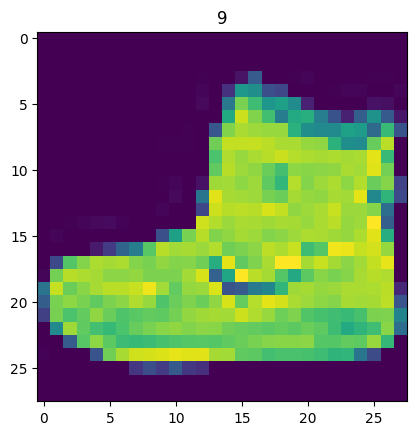

In [8]:
import matplotlib.pyplot as plt

image,label=train_data[0]
print(f"images shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

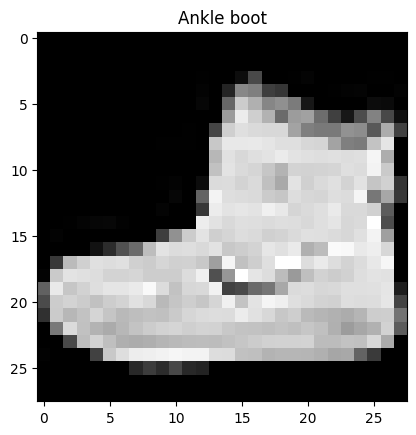

In [9]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])

37542
46067
46876
46414
10026
27335
38620
11924
14950
57113
31378
29014
47210
18954
18231
47572


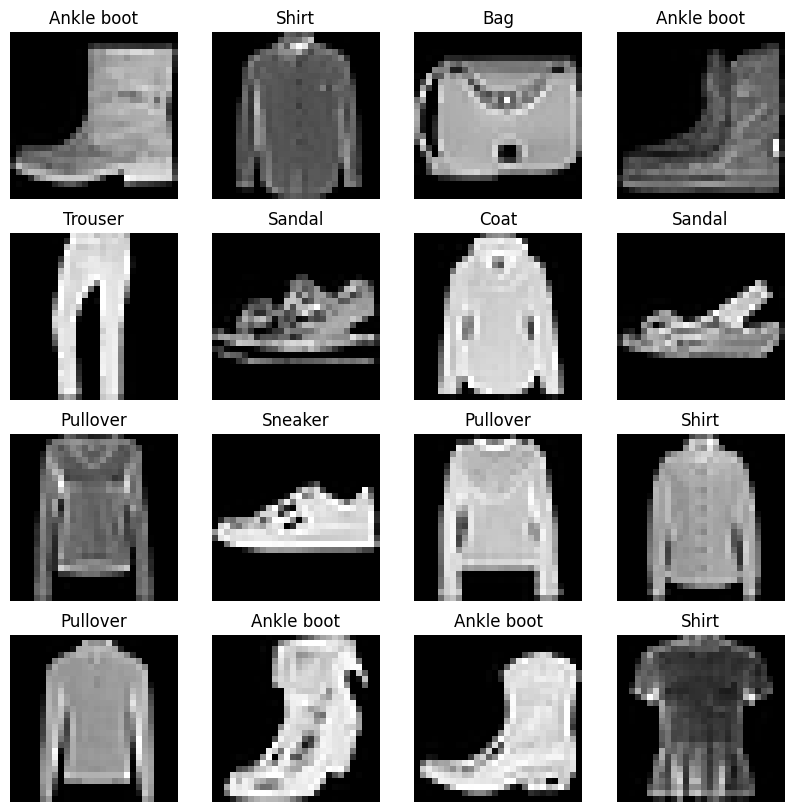

In [10]:
#plot more images
torch.manual_seed(42)
figure=plt.figure(figsize=(10,10))
rows,cols=4,4
for i in range(1,rows*cols+1):
    random_idx=torch.randint(0,len(train_data),size=[1]).item()
    print(random_idx)
    image,label=train_data[random_idx]
    figure.add_subplot(rows,cols,i)
    plt.imshow(image.squeeze(),cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

do you think items of clothing images could be modelled with pure line or do you think with non linear

In [11]:
test_data,train_data

(Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor())

from numpy import iterable
# prepare dataloader
 right now ,our data is in the form of pytorch database
 dataloader turn our dataset in to python iterable
 more specifically we want to turn our data in to batches or mini batches

 1. why?
 bcz more computationally efficent  

 2. it gives our neural network more chance to updated it gradient per epoch



In [12]:
#import the data loader
from torch.utils.data import DataLoader
# turning the train data in to small batches
train_dataloader=DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True
)
test_dataloader=DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False
)

train_dataloader,test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7da941510d40>,
 <torch.utils.data.dataloader.DataLoader at 0x7da9405c7ec0>)

In [13]:
# let cehck out what we had created
print(f"dataloader :{train_dataloader,test_dataloader}")
print(f"length of train dataloader :{len(train_dataloader)}")
print(f"length of test dataloader :{len(test_dataloader)}")

dataloader :(<torch.utils.data.dataloader.DataLoader object at 0x7da941510d40>, <torch.utils.data.dataloader.DataLoader object at 0x7da9405c7ec0>)
length of train dataloader :1875
length of test dataloader :313


In [14]:
# check out whats inside the training loader
train_features_batch,train_labels_batch=next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 8, label size: torch.Size([])


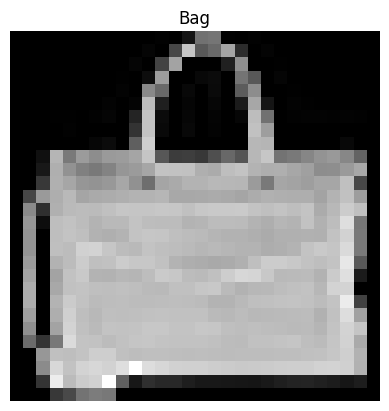

In [15]:
# Show a sample
#torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

### model_0 build the model
we starting  to build a series of the machine learning modeling experiment its best practice to start with base model

In [16]:
# create a flatten feature
flatten_model=nn.Flatten()

# get the single feature
x=train_features_batch[0]
output=flatten_model(x)
print(f"shape before flatten:{x.shape}") # -> colour_channels,height,width
print(f"shape after flatten:{output.shape}") # -> colour_channels,heighyt*weight
#

shape before flatten:torch.Size([1, 28, 28])
shape after flatten:torch.Size([1, 784])


In [17]:
# create the model
from torch import nn
class FashionModel(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int):

    super().__init__()

    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features=input_shape,
            out_features=hidden_units
        ),
        nn.Linear(
            in_features=hidden_units,
            out_features=output_shape

        )
    )
  def forward(self,x):
    return self.layer_stack(x)

In [18]:
torch.manual_seed(42)
model_0=FashionModel(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
)
model_0

FashionModel(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [19]:
dummy_x=torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [20]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### loss and optimization
* loss function -  since we working with multi class data our loss function will be nn.Cross Entropy loss()
* optmizer - torch.optmin.SGD


In [21]:
import requests
from pathlib import Path

# download the helper function from learn pytorch repo
if Path ("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("downloading helper_functions.py")
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

downloading helper_functions.py


In [22]:
# import accuracy metrics by helper function
from helper_functions import accuracy_fn
# set up loss function and optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.1)

### create the function to time our experiments

machine learning is experimental

two of the main things to track is
*  models perfromance( loss /acc values)
*  how fast it run

In [23]:
from timeit import default_timer
def print_train_time(start:float,
                     end:float,
                     device:torch.device=None):
  '''print the diff between the start and the end time'''
  total_Time=end-start
  print(f"train time on {device} : {total_Time:.3f} seconds")
  return total_Time


In [24]:
start_time=default_timer()
end_time=default_timer()
print_train_time(start=start_time,end=end_time,device="cpu")

train time on cpu : 0.000 seconds


4.987500000197542e-05

### creating a training loop and testing a model on batches of data
Let's step through it:

* Loop through epochs.
* Loop through training batches, perform training * steps, calculate the train loss per batch.
* Loop through testing batches, perform testing steps, calculate the test loss per batch.
* Print out what's happening.
* Time it all (for fun).

In [25]:
# import tqdm.auto for the progress bar
from tqdm.auto import tqdm
# set the seed and start the timer

torch.manual_seed(42)
train_time_start_on_cpu=default_timer()

# set the epoch
epochs=3

# creating the training and test loop

for epoch in tqdm(range(epochs)):
  train_loss=0
  for batch ,(X,y) in enumerate(train_dataloader):
    model_0.train()
    #forward method
    y_pred=model_0(X)

    # loss function per batch
    loss=loss_fn(y_pred,y)
    train_loss+=loss

    # optimizer zero grad
    optimizer.zero_grad()
    #back propagation
    loss.backward()

    # optimizer step
    optimizer.step()
    # print what is happening

    if batch %400 ==0:
      print(f"looked at {batch * len(X)}/ {len({train_dataloader.dataset})}")
  train_loss/=len(train_dataloader)
  ## testing loop
  test_loss,test_acc=0,0
  model_0.eval()
  with torch.inference_mode():
    for X,y in test_dataloader:
      test_pred=model_0(X)
      test_loss+=loss_fn(test_pred,y)
      test_acc+=accuracy_fn(y_true=y,
                            y_pred=test_pred.argmax(dim=1))
  # cal the test loss average per batch
    test_loss/=len(test_dataloader)
  # cal the test accuracy per batch
    test_acc/=len(test_dataloader)
  print(f"train loss: {train_loss:.4f} | test loss: {test_loss:.4f} | test acc: {test_acc:.4f}")
  # calculating the time
  train_time_end_on_cpu=default_timer()
  total_train_time_model_0=print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device="cpu"
                                            )


  0%|          | 0/3 [00:00<?, ?it/s]

looked at 0/ 1
looked at 12800/ 1
looked at 25600/ 1
looked at 38400/ 1
looked at 51200/ 1
train loss: 0.5904 | test loss: 0.5095 | test acc: 82.0387
train time on cpu : 9.275 seconds
looked at 0/ 1
looked at 12800/ 1
looked at 25600/ 1
looked at 38400/ 1
looked at 51200/ 1
train loss: 0.4763 | test loss: 0.4799 | test acc: 83.1969
train time on cpu : 17.634 seconds
looked at 0/ 1
looked at 12800/ 1
looked at 25600/ 1
looked at 38400/ 1
looked at 51200/ 1
train loss: 0.4550 | test loss: 0.4766 | test acc: 83.4265
train time on cpu : 29.719 seconds


Make the predictions and get  model_0 result

In [26]:
torch.manual_seed(42)
def eval_model(
    model:torch.nn.Module,
    data_loader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    accuracy_fn,
):
#returns a dictionary containin gthe result of the model predicting on data loaders
  loss,acc=0,0
  model_0.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      y_pred=model_0(X)

      loss+=loss_fn(y_pred,y)
      acc+=accuracy_fn(y_true=y,
                       y_pred=y_pred.argmax(dim=1))
      loss/=len(data_loader)
      acc/=len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when  model created by class
          "model_loss":loss.item(),
          "model_acc":acc}

model_0_res=eval_model(
    model=model_0,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_0_res

{'model_name': 'FashionModel',
 'model_loss': 0.0010611428879201412,
 'model_acc': 0.30028917735831345}

### getting the device agnostic code and mainly for the gpu stuff

In [27]:
torch.cuda.is_available()

True

In [28]:
# set up the device agnostic code
torch.manual_seed(42)
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### model 1 building the  model with non linearity for imporvement

In [29]:
# create the model with the non linearn and linear layers
from torch import nn

class FashionModelv2(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(), # Add Flatten layer here
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )
  def forward(self,x:torch.Tensor):
    return self.layer_stack(x)

In [30]:
# create an instance of the model
torch.manual_seed(42)
model_1=FashionModelv2(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)).to(device)  # send to the
next(model_1.parameters()).device

device(type='cuda', index=0)

#### create the loss,optimizer and evaluation metrics

In [31]:
from helper_functions import accuracy_fn
# set up loss function and optimizer
loss=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_1.parameters(),
                          lr=0.1)

#### create   the training and testing loop

In [32]:
def train_step(model:torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device=device):
  """performs a training with model trying to learn data_loader."""
  train_loss,train_acc=0,0
  model.train()

 # add a loop to loop through the training batches
  for batch ,(X,y) in enumerate(data_loader):

      # put on the target device
      X,y=X.to(device),y.to(device)
      # forward method
      y_pred=model(X)

      # loss function per batch
      loss=loss_fn(y_pred,y)
      train_loss+=loss
      acc=accuracy_fn(y_true=y,
                      y_pred=y_pred.argmax(dim=1)) # going from logit to prediction labels
      train_acc+=acc

      # optimize to zero
      optimizer.zero_grad()
      # back propagation
      loss.backward()
      # optimizer step()
      optimizer.step()

  # cal the  total train loss and accuracy per batch
  train_loss/=len(data_loader)
  train_acc/=len(data_loader)
  print(f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f}")

In [33]:
def test_step(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accuracy_fn,
              device:torch.device=device):

  test_loss,test_acc=0,0
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y=X.to(device),y.to(device)
      test_pred=model(X)
      test_loss+=loss_fn(test_pred,y)
      test_acc+=accuracy_fn(y_true=y,
                            y_pred=test_pred.argmax(dim=1))
    test_loss/=len(data_loader)
    test_acc/=len(data_loader)
    print(f"test loss: {test_loss:.4f} | test acc: {test_acc:.4f}")

Question: "I used a GPU but my model didn't train faster, why might that be?"

Answer: Well, one reason could be because your dataset and model are both so small (like the dataset and model we're working with) the benefits of using a GPU are outweighed by the time it actually takes to transfer the data there.

There's a small bottleneck between copying data from the CPU memory (default) to the GPU memory.

So for smaller models and datasets, the CPU might actually be the optimal place to compute on.

But for larger datasets and models, the speed of computing the GPU can offer usually far outweighs the cost of getting the data there.

However, this is largely dependent on the hardware you're using. With practice, you will get used to where the best place to train your models is

In [34]:
torch.manual_seed(42)
# measure time
from timeit import default_timer as time
train_time_start_on_gpu=time()

# set the epoch
epochs=3

for epoch in tqdm(range(epochs)):
  print(f"epoch: {epoch}\n-------")
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_on_gpu=time()
total_train_time_model_1=print_train_time(start=train_time_start_on_gpu,
                                          end=train_time_end_on_gpu,
                                          device="gpu")
print(f"model_1 train time: {total_train_time_model_1}")

  0%|          | 0/3 [00:00<?, ?it/s]

epoch: 0
-------
train loss: 0.6677 | train acc: 75.8833
test loss: 0.5009 | test acc: 82.0887
epoch: 1
-------
train loss: 0.4834 | train acc: 82.7717
test loss: 0.4890 | test acc: 82.6877
epoch: 2
-------
train loss: 0.4496 | train acc: 83.8717
test loss: 0.4858 | test acc: 82.8874
train time on gpu : 37.329 seconds
model_1 train time: 37.328674143


In [35]:
# train time on cpu

total_train_time_model_0

29.718990037999987

 get the model_1 results dictionarymodel_1.state_dict()

In [36]:
torch.manual_seed(42)

# Note: This will error due to `eval_model()` not using device agnostic code
model_1_results = eval_model(model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn)
model_1_results ,model_0_res

({'model_name': 'FashionModelv2',
  'model_loss': 0.0010611428879201412,
  'model_acc': 0.30028917735831345},
 {'model_name': 'FashionModel',
  'model_loss': 0.0010611428879201412,
  'model_acc': 0.30028917735831345})

### Building  the CNN model
resources to cover and get the undersganding of cnn : https://poloclub.github.io/cnn-explainer/

In [39]:
# create  the model
class FashionCNN(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    # create the convo layer
    self.conv_block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                 kernel_size=3,
                 stride=1,
                 padding=1), # values we can set oursleves in our nn


    nn.ReLU(),
    nn.Conv2d(in_channels=hidden_units,
              out_channels=hidden_units,
              kernel_size=3
              ,stride=1,
              padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2))
    self.conv_block2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def foward(self,x):
    return self.classifier(self.conv_block2(self.conv_block_1(x)))


In [41]:
torch.manual_seed(42)
model_2=FashionCNN(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)
